## Importando bibliotecas


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error
%matplotlib inline

## Obtendo Dados

In [2]:
#Setting the names of the columns
name_columns = ["ESCT","NDEP","RENDA","TIPOR","VBEM","NPARC","VPARC","TEL","IDADE","RESMS","ENTRADA", "CLASSE"]

#Loading the datasets
df_test = pd.read_csv('credtest.txt', sep='\t', header=None)
df_test.columns = name_columns
df_train = pd.read_csv('credtrain.txt', sep='\t', header=None)
df_train.columns = name_columns


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ESCT     1500 non-null   int64
 1   NDEP     1500 non-null   int64
 2   RENDA    1500 non-null   int64
 3   TIPOR    1500 non-null   int64
 4   VBEM     1500 non-null   int64
 5   NPARC    1500 non-null   int64
 6   VPARC    1500 non-null   int64
 7   TEL      1500 non-null   int64
 8   IDADE    1500 non-null   int64
 9   RESMS    1500 non-null   int64
 10  ENTRADA  1500 non-null   int64
 11  CLASSE   1500 non-null   int64
dtypes: int64(12)
memory usage: 140.8 KB


## Confering the data labes

In [4]:
list_data = [set(df_train[i].to_list()) for i in df_train.columns ]
for i in list_data:
    print(f"Column: {df_train.columns[list_data.index(i)]}, Min: {min(i)}, Max: {max(i)} " )

Column: ESCT, Min: 0, Max: 3 
Column: NDEP, Min: 0, Max: 7 
Column: RENDA, Min: 300, Max: 8000 
Column: TIPOR, Min: 0, Max: 1 
Column: VBEM, Min: 300, Max: 4000 
Column: NPARC, Min: 1, Max: 24 
Column: VPARC, Min: 50, Max: 711 
Column: TIPOR, Min: 0, Max: 1 
Column: IDADE, Min: 19, Max: 70 
Column: RESMS, Min: 0, Max: 420 
Column: ENTRADA, Min: 0, Max: 1300 
Column: TIPOR, Min: 0, Max: 1 


Esse conjunto de dados contém diversos atributos que são categóricos. Modelos de AM não podem ser treinados no Scikit-Learn sobre atributos cujos valores são cadeias de caracteres. Sendo assim, você deve tomar providências para codificar numericamente esses atributos de maneira apropriada.

Dentre os atributos numéricos, há uma grande discrepância entre as suas respectivas faixas de valores. É sabido que diferenças grandes entre as faixas de valores dos atributos numéricos pode atrapalhar o processo de treinamento de alguns algoritmos de AM

## Standard variables

In [5]:
dict_classification = {
    "NormalizedData": [],
    "StandardData": [],
    "RobustData": []
}

#Standardization is not recommended for data with outliers
#1. Normalization: scales the data to a range of [0, 1]
scaler_normalized = MinMaxScaler()
normalized_data_train = scaler_normalized.fit_transform(df_train.drop('CLASSE',axis=1))
normalized_data_test = scaler_normalized.transform(df_test.drop('CLASSE',axis=1))

#2. Standardization: scales the data to a mean of 0 and a standard deviation of 1   
scaler_standard = StandardScaler()
standard_data_train = scaler_standard.fit_transform(df_train.drop('CLASSE',axis=1))
standard_data_test = scaler_standard.transform(df_test.drop('CLASSE',axis=1))

#3. RobustScaler: scales the data using statistics that are robust to outliers
scaler_robuster = RobustScaler()
robust_data_train = scaler_robuster.fit_transform(df_train.drop('CLASSE',axis=1))
robust_data_test = scaler_robuster.transform(df_test.drop('CLASSE',axis=1))

## Division train-test
We will divide the data between the train and tests

In [7]:
#1. Normalization: scales the data to a range of [0, 1]
# X_train_normalized_data, X_test_normalized_data, y_train_normalized_data, y_test_normalized_data = train_test_split(normalized_data_train,df_train['CLASSE'],
#                                                     test_size=1)
X_train_normalized_data, y_train_normalized_data = normalized_data_train, df_train['CLASSE']
X_test_normalized_data, y_test_normalized_data = normalized_data_test, df_test['CLASSE']
list_normalized = [X_train_normalized_data, X_test_normalized_data, y_train_normalized_data, y_test_normalized_data, "NormalizedData"]

#2. Standardization: scales the data to a mean of 0 and a standard deviation of 1   
# X_train_standard_data, X_test_standard_data, y_train_standard_data, y_test_standard_data_train = train_test_split(standard_data_train,df_train['CLASSE'],
#                                                     test_size=1)
X_train_standard_data, y_train_standard_data = standard_data_train, df_train['CLASSE']
X_test_standard_data, y_test_standard_data = standard_data_test, df_test['CLASSE']
list_standard = [X_train_standard_data, X_test_standard_data, y_train_standard_data, y_test_standard_data, "StandardData"]

#3. RobustScaler
# X_train_robust_data, X_test_robust_data, y_train_robust_data, y_test_robust_data = train_test_split(robust_data_train,df_train['CLASSE'],
#                                                     test_size=1)
X_train_robust_data, y_train_robust_data = robust_data_train, df_train['CLASSE']
X_test_robust_data, y_test_robust_data = robust_data_test, df_test['CLASSE']
list_robust = [X_train_robust_data, X_test_robust_data, y_train_robust_data, y_test_robust_data, "RobustData"]

## Classification Methods

Logistic Regression

Method: NormalizedData
Coefficients: 
 [[ 0.32842336  0.37319768  0.15426999 -3.7593808   0.97731873  3.21020879
   0.19894366  0.10034024 -6.8033862   1.71615049 -0.99661618]]
Confusion Matrix:
[[296  10]
 [ 50 221]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       306
           1       0.96      0.82      0.88       271

    accuracy                           0.90       577
   macro avg       0.91      0.89      0.89       577
weighted avg       0.90      0.90      0.90       577

MAE: 0.104
MSE: 0.104
RMSE: 0.322

--------------------------------------------------------------------------------

Method: StandardData
Coefficients: 
 [[ 0.07447763  0.06551865  0.0589563  -2.20140819  0.22068383  0.63835506
   0.00283604 -0.01505602 -2.17883595  0.37851102 -0.16285829]]
Confusion Matrix:
[[288  18]
 [ 47 224]]

Classification Report:
              precision    recall  f1-score   support

           0       

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


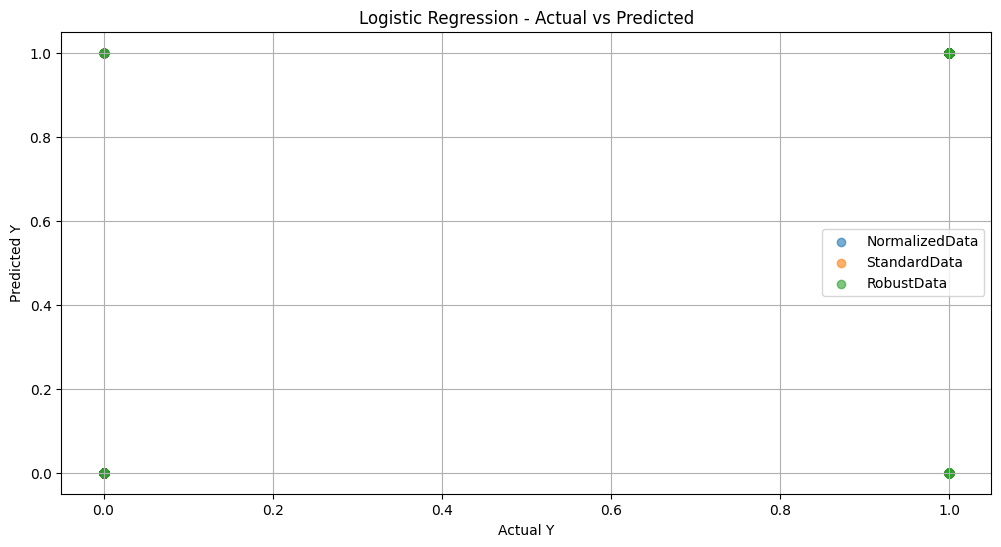

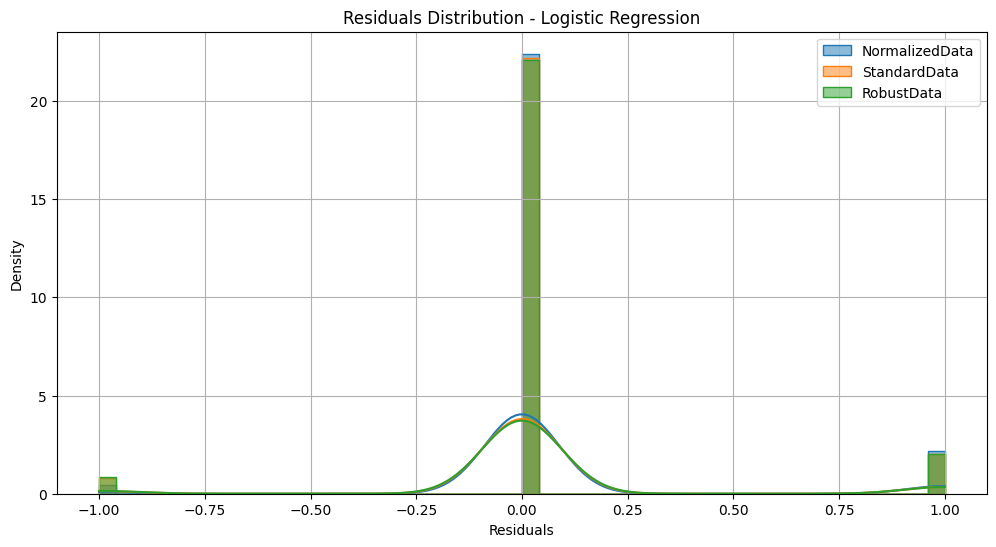

In [32]:
# Logistic Regression for each preprocessing method
# Dictionary to store predictions and residuals for combined plots
predictions = {}
residuals = {}

# Logistic Regression for each preprocessing method
for list_data in [list_normalized, list_standard, list_robust]:
    lm = LogisticRegression()
    X_train, X_test, y_train, y_test, method = list_data
    print(f"Method: {method}")
    
    # Fit the model to the training data
    lm.fit(X_train, y_train)

    # Display coefficients
    print('Coefficients: \n', lm.coef_)
    
    # Make predictions
    pred = lm.predict(X_test)
    predictions[method] = (y_test, pred)
    residuals[method] = y_test - pred

    # Evaluation metrics
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print('\nClassification Report:')
    print(classification_report(y_test, pred))

    print('MAE:', round(mean_absolute_error(y_test, pred), 3))
    print('MSE:', round(mean_squared_error(y_test, pred), 3))
    print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))
    print('\n' + '-'*80 + '\n')

# Plot all scatter plots in one figure
plt.figure(figsize=(12, 6))
for method, (y_test, pred) in predictions.items():
    plt.scatter(y_test, pred, label=method, alpha=0.6)
plt.title('Logistic Regression - Actual vs Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.legend()
plt.grid(True)
plt.show()

# Plot all residual histograms in one figure
plt.figure(figsize=(12, 6))
for method, resid in residuals.items():
    sns.histplot(resid, bins=50, kde=True, label=method, stat='density', element='step')
plt.title('Residuals Distribution - Logistic Regression')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


Knn

Best k for NormalizedData: 5
Error rate for NormalizedData: 0.114
Confusion Matrix:
[[291  15]
 [ 51 220]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       306
           1       0.94      0.81      0.87       271

    accuracy                           0.89       577
   macro avg       0.89      0.88      0.88       577
weighted avg       0.89      0.89      0.88       577

MAE: 0.114
MSE: 0.114
RMSE: 0.338

--------------------------------------------------------------------------------

Best k for StandardData: 23
Error rate for StandardData: 0.118
Confusion Matrix:
[[292  14]
 [ 54 217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.90       306
           1       0.94      0.80      0.86       271

    accuracy                           0.88       577
   macro avg       0.89      0.88      0.88       577
weighted avg       0.89  

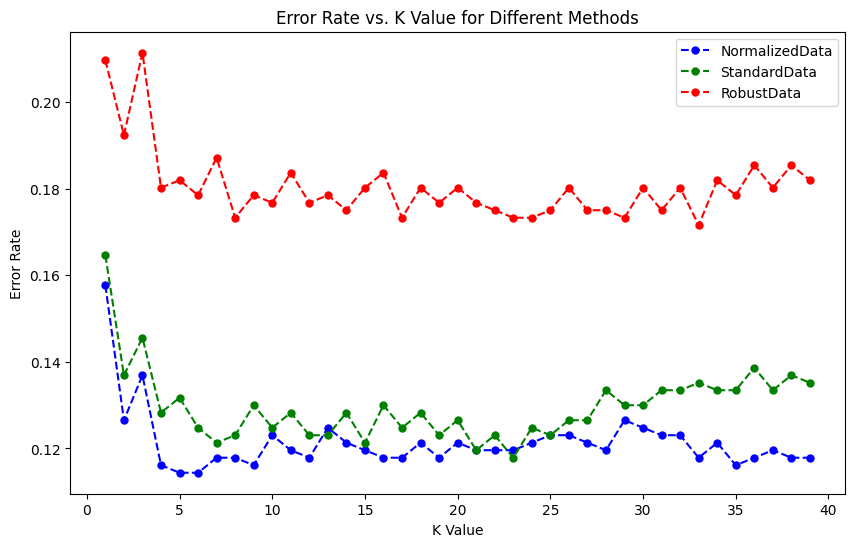

In [30]:
# KNN Classifier
# Initialize the KNN classifier

# Dictionary to store error rates for each method
error_rates_dict = {}

# Loop over each preprocessing method's data list
# Each list should be in the format:
# [X_train, X_test, y_train, y_test, method_name]
for list_data in [list_normalized, list_standard, list_robust]:
    X_train, X_test, y_train, y_test, method = list_data
    error_rate = []

    # Finding the best K value by iterating K from 1 to 39
    for k in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)
        error_rate.append(np.mean(pred_i != y_test))
    
    # Store the error rate curve for this method
    error_rates_dict[method] = error_rate

    # Determine the best K (adding +1 because k starts at 1)
    best_k = np.argmin(error_rate) + 1
    print(f"Best k for {method}: {best_k}")
    print(f"Error rate for {method}: {round(min(error_rate), 3)}")

    # Train KNN with the best k and evaluate the model
    knn_best_k = KNeighborsClassifier(n_neighbors=best_k)
    knn_best_k.fit(X_train, y_train)
    pred_best_k = knn_best_k.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred_best_k))
    print("\nClassification Report:")
    print(classification_report(y_test, pred_best_k))

    # Calculate error metrics
    print('MAE:', round(mean_absolute_error(y_test, pred_best_k), 3))
    print('MSE:', round(mean_squared_error(y_test, pred_best_k), 3))
    print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_best_k)), 3))
    print("\n" + "-"*80 + "\n")

# Plot all error rate curves in one plot
plt.figure(figsize=(10, 6))

# Define colors for each method
colors = {'NormalizedData': 'blue', 'StandardData': 'green', 'RobustData': 'red'}

for method, error_rate in error_rates_dict.items():
    plt.plot(range(1, 40), error_rate, linestyle='dashed', marker='o',
             markerfacecolor=colors.get(method, 'black'), markersize=5,
             color=colors.get(method, 'black'), label=method)

plt.title('Error Rate vs. K Value for Different Methods')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend()
plt.show()


Gradient Boosting

Best n_estimators for NormalizedData: 90
Lowest error rate for NormalizedData: 0.092
Confusion Matrix:
[[298   8]
 [ 45 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       306
           1       0.97      0.83      0.90       271

    accuracy                           0.91       577
   macro avg       0.92      0.90      0.91       577
weighted avg       0.91      0.91      0.91       577

MAE: 0.092
MSE: 0.092
RMSE: 0.303

--------------------------------------------------------------------------------

Best n_estimators for StandardData: 90
Lowest error rate for StandardData: 0.092
Confusion Matrix:
[[298   8]
 [ 45 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       306
           1       0.97      0.83      0.90       271

    accuracy                           0.91       577
   macro avg       0.92      0.90      0.9

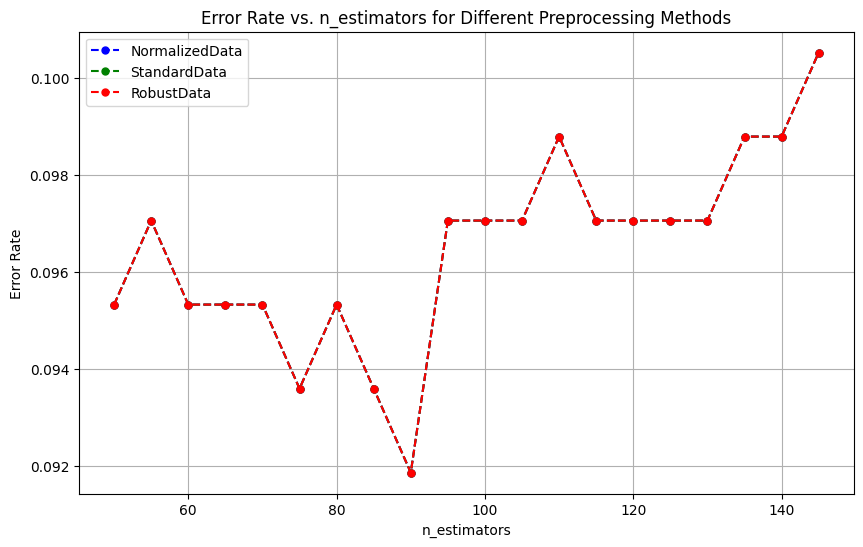

In [31]:
# Gradient Boosting Classifier
# Dictionary to store error rates for each preprocessing method
error_rates_gbc = {}

# Gradient Boosting Classifier evaluation for each data preprocessing method
for list_data in [list_normalized, list_standard, list_robust]:
    X_train, X_test, y_train, y_test, method = list_data
    error_rate = []

    # Define the range of n_estimators to test
    n_estimators_range = range(50, 150, 5)  # from 50 to 145, stepping by 5

    for n in n_estimators_range:
        gbc = GradientBoostingClassifier(n_estimators=n, random_state=42)
        gbc.fit(X_train, y_train)
        pred_i = gbc.predict(X_test)
        error_rate.append(np.mean(pred_i != y_test))

    # Store error rates for plotting
    error_rates_gbc[method] = error_rate

    # Find best n_estimators value
    best_n = list(n_estimators_range)[np.argmin(error_rate)]
    print(f"Best n_estimators for {method}: {best_n}")
    print(f"Lowest error rate for {method}: {round(min(error_rate), 3)}")

    # Train the final model using the best n_estimators
    gbc_best = GradientBoostingClassifier(n_estimators=best_n, random_state=42)
    gbc_best.fit(X_train, y_train)
    pred_best = gbc_best.predict(X_test)

    # Output evaluation metrics
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred_best))
    print("\nClassification Report:")
    print(classification_report(y_test, pred_best))

    print("MAE:", round(mean_absolute_error(y_test, pred_best), 3))
    print("MSE:", round(mean_squared_error(y_test, pred_best), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_best)), 3))
    print("\n" + "-"*80 + "\n")

# Plot all error rate curves on the same graph
plt.figure(figsize=(10, 6))
colors = {'NormalizedData': 'blue', 'StandardData': 'green', 'RobustData': 'red'}

for method, error_rate in error_rates_gbc.items():
    plt.plot(list(range(50, 150, 5)), error_rate, linestyle='dashed', marker='o',
             markerfacecolor=colors.get(method, 'black'), markersize=5,
             color=colors.get(method, 'black'), label=method)

plt.title('Error Rate vs. n_estimators for Different Preprocessing Methods')
plt.xlabel('n_estimators')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)
plt.show()
